In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/bigbasket_products.csv")

In [3]:
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [4]:
df.tail()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
27550,27551,"Wottagirl! Perfume Spray - Heaven, Classic",Beauty & Hygiene,Fragrances & Deos,Layerr,199.20,249.0,Perfume,3.9,Layerr brings you Wottagirl Classic fragrant b...
27551,27552,Rosemary,Gourmet & World Food,Cooking & Baking Needs,Puramate,67.50,75.0,"Herbs, Seasonings & Rubs",4.0,Puramate rosemary is enough to transform a dis...
27552,27553,Peri-Peri Sweet Potato Chips,Gourmet & World Food,"Snacks, Dry Fruits, Nuts",FabBox,200.00,200.0,Nachos & Chips,3.8,We have taken the richness of Sweet Potatoes (...
27553,27554,Green Tea - Pure Original,Beverages,Tea,Tetley,396.00,495.0,Tea Bags,4.2,"Tetley Green Tea with its refreshing pure, ori..."
27554,27555,United Dreams Go Far Deodorant,Beauty & Hygiene,Men's Grooming,United Colors Of Benetton,214.53,390.0,Men's Deodorants,4.5,The new mens fragrance from the United Dreams ...


In [5]:
df.shape

(27555, 10)

In [6]:
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [8]:
df.describe()

,index,sale_price,market_price,rating
count,27555.00000,27555.000000,27555.000000,18929.000000
mean,13778.00000,322.514808,382.056664,3.943410
std,7954.58767,486.263116,581.730717,0.739063
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.000000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,12500.000000,12500.000000,5.000000


In [9]:
df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description      115
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df = df.dropna(subset=["product"])


In [13]:
df["rating"] = df["rating"].fillna(0)


In [14]:
df["description"] = df["description"].fillna("Not Available")

In [15]:
df["brand"] = df["brand"].fillna("Unknown")

In [16]:
df.isnull().sum()

index           0
product         0
category        0
sub_category    0
brand           0
sale_price      0
market_price    0
type            0
rating          0
description     0
dtype: int64

In [17]:
# Exploratory Data Analysis

In [18]:
print("Total Products :", len(df))

Total Products : 27554


In [19]:
print("Total Categories :", df["category"].nunique())

Total Categories : 11


In [20]:
print("Total Brands :", df["brand"].nunique())

Total Brands : 2314


In [21]:
print("Average Rating :", round(df["rating"].mean(), 2))

Average Rating : 2.71


In [22]:
print("Highest Sale Price :", df["sale_price"].max())

Highest Sale Price : 12500.0


In [23]:
print("Lowest Sale Price :", df["sale_price"].min())

Lowest Sale Price : 2.45


C:\Users\vamshith\AppData\Local\Temp\ipykernel_27120\1296593635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


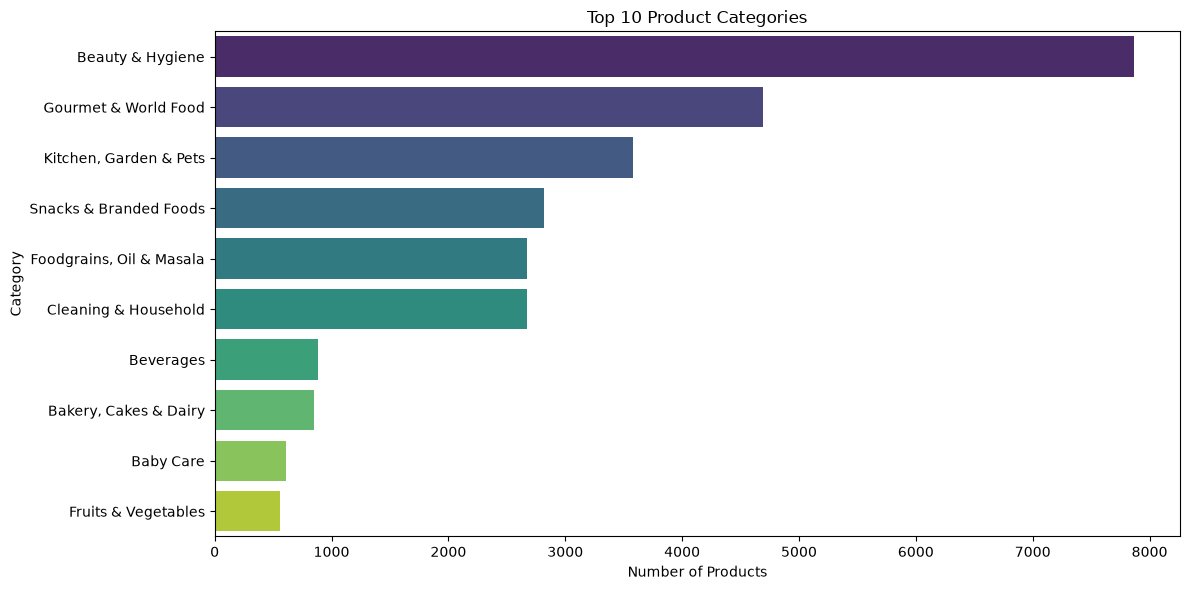

In [24]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="category",
    data=df,
    order=df["category"].value_counts().index[:10],
    palette="viridis"
)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

C:\Users\vamshith\AppData\Local\Temp\ipykernel_27120\85344787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


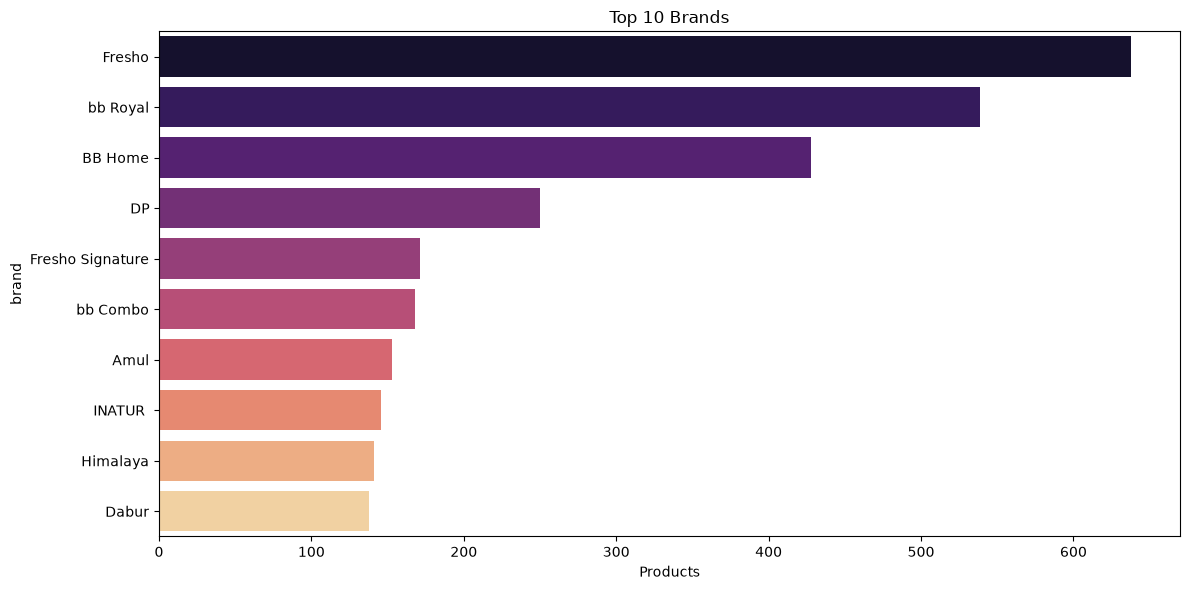

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="brand",
    data=df,
    order=df["brand"].value_counts().index[:10],
    palette="magma"
)

plt.title("Top 10 Brands")
plt.xlabel("Products")

plt.tight_layout()

plt.show()

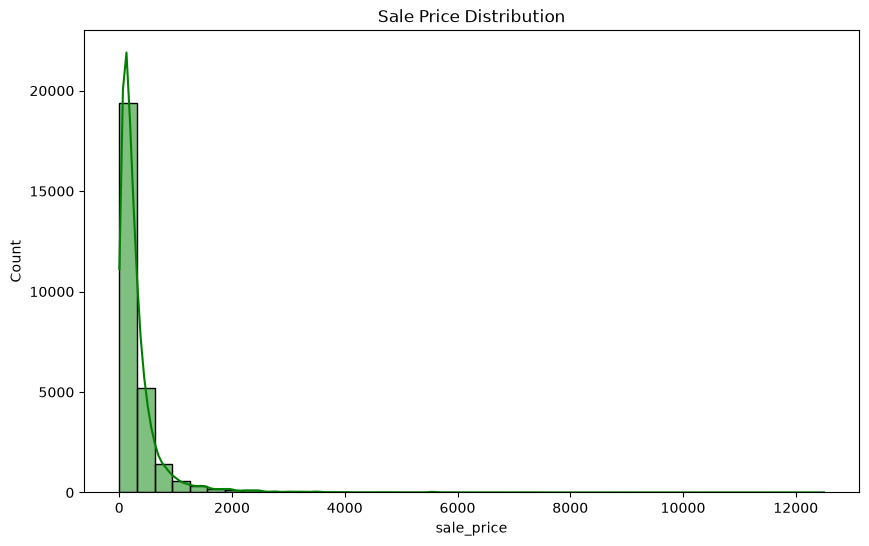

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["sale_price"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Sale Price Distribution")

plt.show()

In [27]:
plt.savefig("../images/top_categories.png")

<Figure size 640x480 with 0 Axes>

In [28]:
# Business Analysis

In [29]:
df["discount_percentage"] = (
    (df["market_price"] - df["sale_price"])
    / df["market_price"]
) * 100

df["discount_percentage"] = df["discount_percentage"].round(2)

df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,discount_percentage
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...,0.00
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ...",0.00
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m...",52.40
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...,15.34
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...,0.00


In [30]:
top_discount = df.sort_values(
    by="discount_percentage",
    ascending=False
)

top_discount[
    ["product", "brand", "discount_percentage"]
].head(10)

,product,brand,discount_percentage
26976,Curry Leaves,Fresho,83.67
17713,Fruit & Vegetables Hand Juicer,Triones,82.51
13318,Small Silicone Spatula With Plastic Handle - A...,HAZEL,81.20
13740,Decorative Party Light Big Star String LED Lig...,Lexton,80.98
10438,NHS 860 Temperature Control Professional Hair ...,Nova,80.50
4562,Concealer Brush 930,Mud,80.00
13265,Decorative Party Light Golden Bell String LED ...,Lexton,79.24
11473,Decorative Party Light Golden Bell String LED ...,Lexton,79.24
10092,USB String Fairy Lights 3M 30 LED For Decorati...,Mansaa,78.70
398,Steel Belly Shape Storage Dabba/ Container Set...,Jensons,77.99


In [31]:
category_price = (
    df.groupby("category")["sale_price"]
      .mean()
      .sort_values(ascending=False)
)

category_price

category
Baby Care                   534.946180
Kitchen, Garden & Pets      507.524615
Beauty & Hygiene            418.679197
Gourmet & World Food        319.854011
Eggs, Meat & Fish           288.897486
Beverages                   239.803925
Cleaning & Household        226.173118
Foodgrains, Oil & Masala    193.167500
Bakery, Cakes & Dairy       142.802750
Snacks & Branded Foods      129.593134
Fruits & Vegetables          50.889336
Name: sale_price, dtype: float64

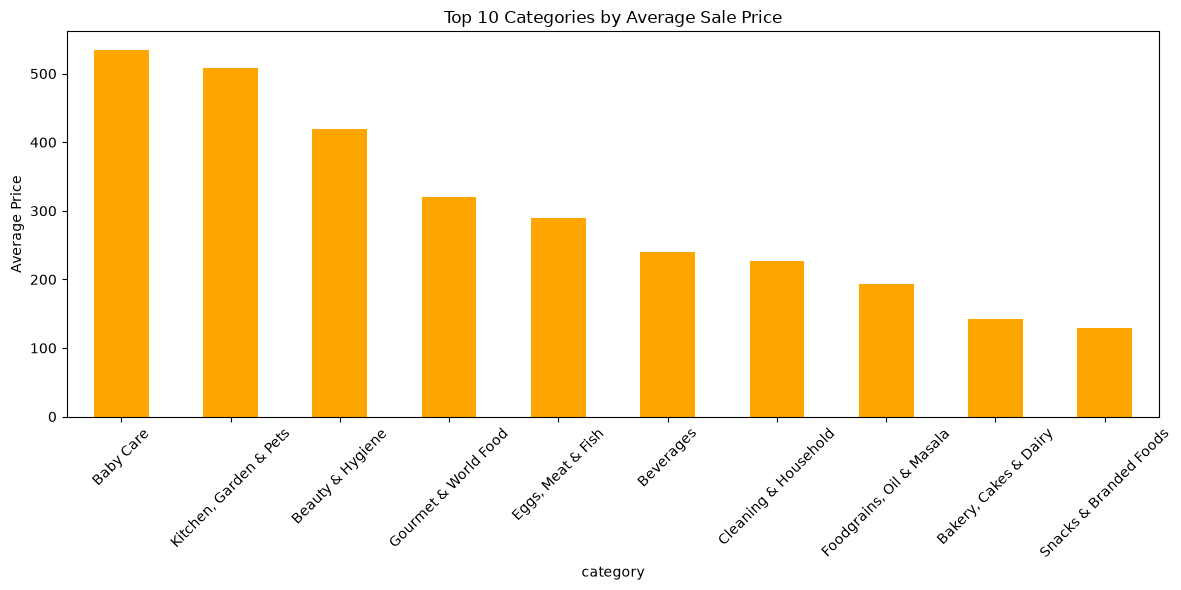

In [32]:
plt.figure(figsize=(12,6))

category_price.head(10).plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 Categories by Average Sale Price")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [33]:
brand_rating = (
    df.groupby("brand")["rating"]
      .mean()
      .sort_values(ascending=False)
)

brand_rating.head(10)

brand
1mg                    5.0
Episoft                5.0
Creme 21               5.0
Godrej Professional    5.0
DIVING DUCK            5.0
Depend                 5.0
Floh                   5.0
Skc                    5.0
BA KABRA               5.0
ENE                    5.0
Name: rating, dtype: float64

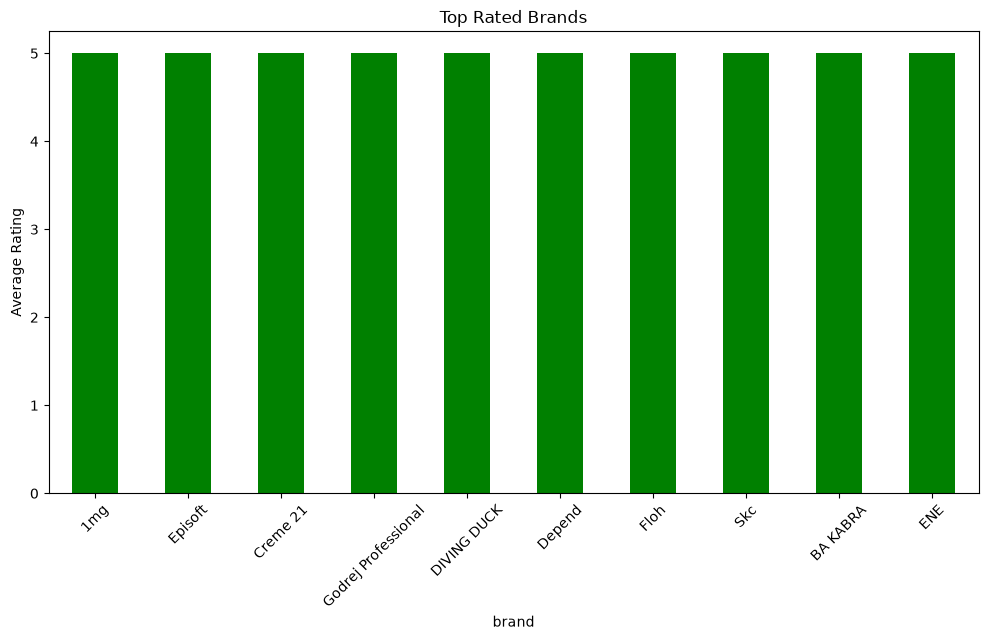

In [34]:
plt.figure(figsize=(12,6))

brand_rating.head(10).plot(
    kind="bar",
    color="green"
)

plt.title("Top Rated Brands")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

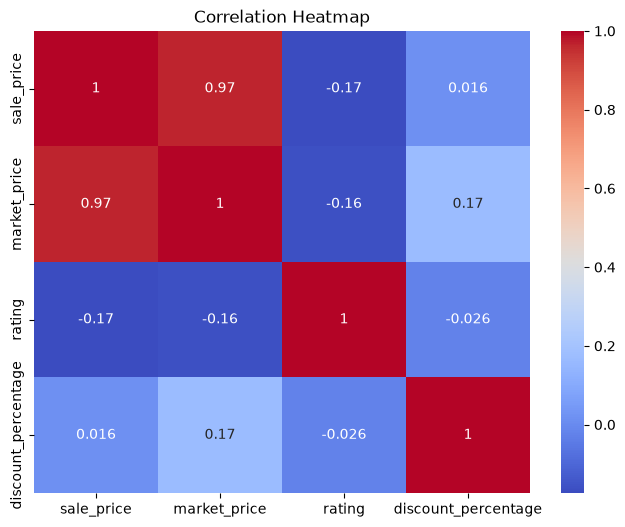

In [35]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            "sale_price",
            "market_price",
            "rating",
            "discount_percentage",
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

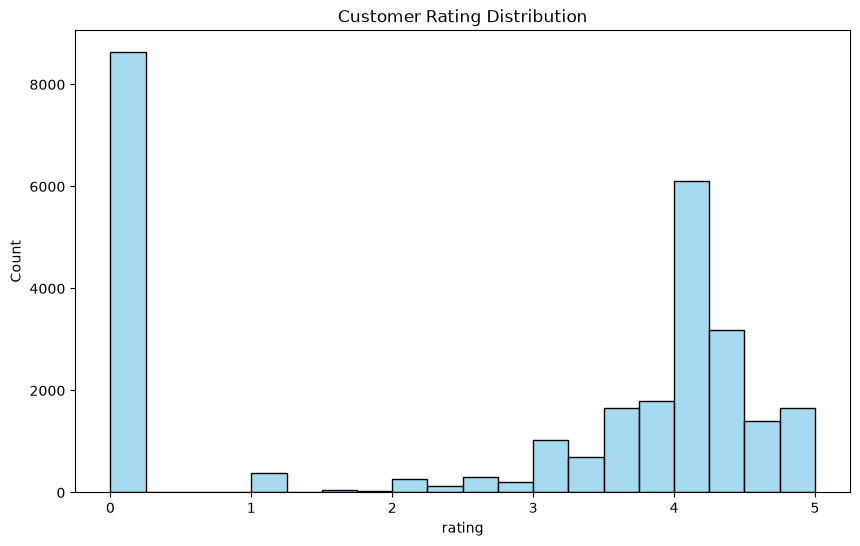

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["rating"],
    bins=20,
    color="skyblue"
)

plt.title("Customer Rating Distribution")

plt.show()

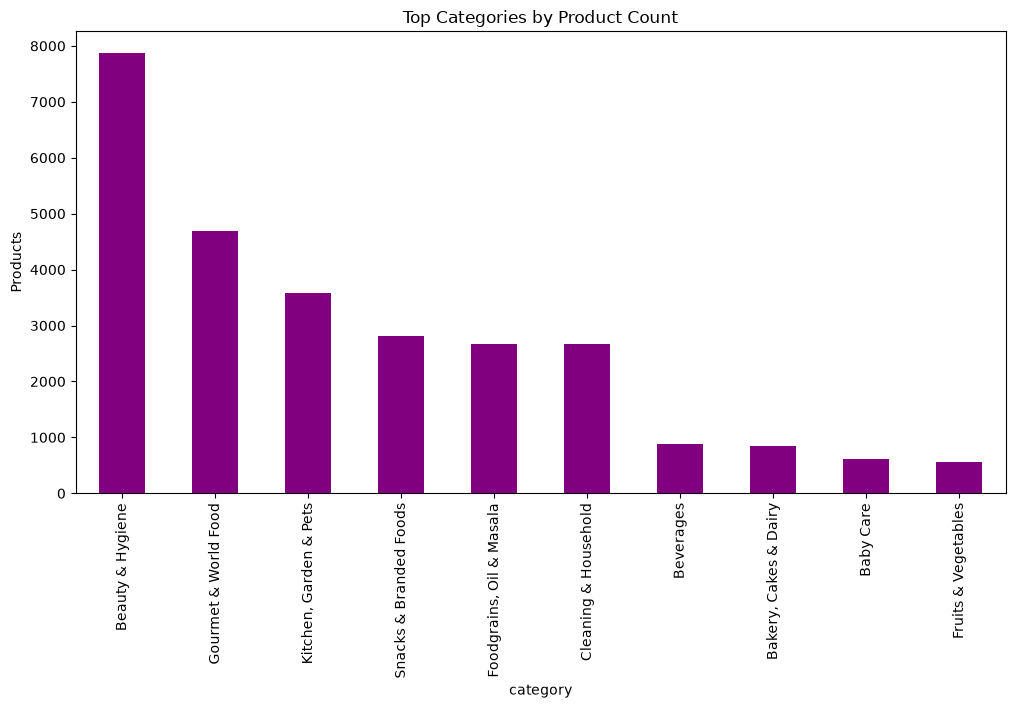

In [37]:
top_categories = df["category"].value_counts().head(10)

plt.figure(figsize=(12,6))

top_categories.plot(
    kind="bar",
    color="purple"
)

plt.title("Top Categories by Product Count")
plt.ylabel("Products")

plt.show()

In [38]:
# Business Insights

1.Products are spread across multiple categories, with a few categories containing the highest number of listings.

2.Premium categories have a higher average selling price.

3.Some products receive very high discounts compared to their market price.

4.Higher-priced products do not always have higher customer ratings.

5.Customer ratings vary across brands, highlighting opportunities for quality improvement.

6.Market price and sale price show a strong positive relationship.

In [39]:
# Conclusion

In [42]:
This analysis explored the BigBasket product dataset to understand pricing, discounts, brand performance, and customer ratings. The findings highlight opportunities for pricing optimization, inventory planning, and identifying popular product categories. Such insights can support business decision-making in retail and e-commerce.

SyntaxError: invalid syntax (3480159887.py, line 1)